# Feature Builder

This notebook is strictly for feature creation and feature plots. It does not build targets, correlations, IC tables, or distribution diagnostics.

Default bucket size is `BAR_MINUTES = 5`. Override with `MODL_BAR_MINUTES=1` or `MODL_BAR_MINUTES=15` before launching Jupyter.

In [1]:
from __future__ import annotations

import os
import sys
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns

if "notebooks" not in sys.path:
    sys.path.append("notebooks")

from advanced_features import (
    build_feature_set,
    discover_datasets,
    latest_feature_date,
    plot_realized_vol,
    plot_term_structure,
)

ROOT = Path(os.environ.get("MODL_WS_NORMALIZED_DIR", "/mnt/burner-archive/ws_normalized")).expanduser()
DATE = os.environ.get("MODL_VIEW_DATE") or latest_feature_date(ROOT)
DATE_TAG = datetime.strptime(DATE, "%Y-%m-%d").strftime("%y-%m-%d")
FEATURE_ROOT = Path(os.environ.get("MODL_WS_FEATURE_DIR", "/mnt/burner-archive/ws_features")).expanduser()
BAR_MINUTES = int(os.environ.get("MODL_BAR_MINUTES", "5"))
HORIZONS = (5, 15, 30)
SAVE_OUTPUTS = False

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 240)
pd.set_option("display.max_colwidth", 180)
pl.Config.set_tbl_cols(240)
pl.Config.set_tbl_rows(24)

DATASETS = discover_datasets(ROOT, DATE_TAG)
if not DATASETS:
    raise FileNotFoundError(f"No normalized Parquet files found under {ROOT} for {DATE}")

ROOT, DATE, DATE_TAG, BAR_MINUTES, len(DATASETS)


(PosixPath('/mnt/burner-archive/ws_normalized'),
 '2026-07-01',
 '26-07-01',
 5,
 14)

## Build 5-Minute Feature Set

In [2]:
feature_set = build_feature_set(DATASETS, horizons=HORIZONS, bar_minutes=BAR_MINUTES)
feature_matrix = feature_set.feature_matrix
base_feature_matrix = feature_set.base_feature_matrix
trade_features = feature_set.trade_features
book_features = feature_set.book_features
deribit_option_features = feature_set.deribit_option_features
term_structure_features = feature_set.term_structure
option_smile_features = feature_set.option_smile
futures_basis_features = feature_set.futures_basis
funding_features = feature_set.funding_features
rv_features = feature_set.rv_features
reference_price = feature_set.reference_price

df = feature_matrix
df_stats = df.describe().T

component_shapes = pd.DataFrame(
    [
        ("feature_matrix", *feature_matrix.shape),
        ("base_feature_matrix", *base_feature_matrix.shape),
        ("trade_features", trade_features.height, trade_features.width),
        ("book_features", book_features.height, book_features.width),
        ("deribit_option_features", *deribit_option_features.shape),
        ("term_structure_features", *term_structure_features.shape),
        ("option_smile_features", *option_smile_features.shape),
        ("futures_basis_features", *futures_basis_features.shape),
        ("funding_features", *funding_features.shape),
        ("rv_features", *rv_features.shape),
    ],
    columns=["component", "rows", "columns"],
)
component_shapes

,component,rows,columns
0,feature_matrix,288,436
1,base_feature_matrix,288,28
2,trade_features,864,10
3,book_features,864,9
4,deribit_option_features,288,5
5,term_structure_features,288,15
6,option_smile_features,288,12
7,futures_basis_features,288,17
8,funding_features,288,2
9,rv_features,288,20


In [3]:
df_stats.head(80)

,count,mean,std,min,25%,50%,75%,max
trade_flow_imbalance_bitfinex,288.0,-0.048437,0.468314,-0.977179,-0.377911,-0.058297,0.289087,0.959110
trade_flow_imbalance_hibachi,288.0,-0.009454,0.428063,-0.931544,-0.334333,0.013421,0.275435,0.999370
trade_flow_imbalance_hyperliquid,288.0,0.075922,0.637854,-0.994719,-0.521204,0.098701,0.701250,0.999144
trade_trade_count_bitfinex,288.0,196.711806,119.372066,51.000000,125.000000,167.000000,224.750000,1071.000000
trade_trade_count_hibachi,288.0,76.111111,52.966903,15.000000,44.000000,60.000000,85.250000,396.000000
...,...,...,...,...,...,...,...,...
smile_atm_call_iv_count,288.0,1141.090278,473.494311,581.000000,812.500000,1025.000000,1303.500000,3936.000000
smile_atm_put_iv_count,288.0,1141.562500,474.194144,581.000000,814.000000,1025.500000,1303.750000,3956.000000
smile_otm_call_iv_count,288.0,842.586806,482.700128,161.000000,528.750000,736.000000,969.500000,3627.000000
smile_otm_put_iv_count,288.0,646.784722,298.618542,285.000000,446.000000,568.500000,745.500000,2531.000000


## Trade Flow Features

In [4]:
trade_features.head(30)

minute,trade_count,volume,notional,signed_volume,buy_count,sell_count,venue,vwap,flow_imbalance
datetime[μs],u32,f64,f64,f64,i64,i64,str,f64,f64
2026-07-01 00:00:00,172,0.5359,31451.308828,0.172589,109,63,"""bitfinex""",58688.764373,0.322054
2026-07-01 00:05:00,117,0.106223,6237.739215,-0.030535,33,84,"""bitfinex""",58723.078463,-0.287458
2026-07-01 00:10:00,120,0.492798,28908.210699,-0.057331,55,65,"""bitfinex""",58661.40015,-0.116337
2026-07-01 00:15:00,149,0.220449,12921.809021,0.06528,48,101,"""bitfinex""",58615.974912,0.296122
2026-07-01 00:20:00,141,0.986542,57682.627465,-0.85713,60,81,"""bitfinex""",58469.502427,-0.868823
2026-07-01 00:25:00,201,3.317441,193683.301431,-1.652415,85,116,"""bitfinex""",58383.34611,-0.498099
2026-07-01 00:30:00,240,1.10732,64749.607803,-0.107547,159,81,"""bitfinex""",58474.180926,-0.097124
2026-07-01 00:35:00,151,0.137708,8050.938131,0.059641,50,101,"""bitfinex""",58463.922387,0.433101
2026-07-01 00:40:00,114,0.0835,4881.80808,0.037963,80,34,"""bitfinex""",58464.578377,0.454649


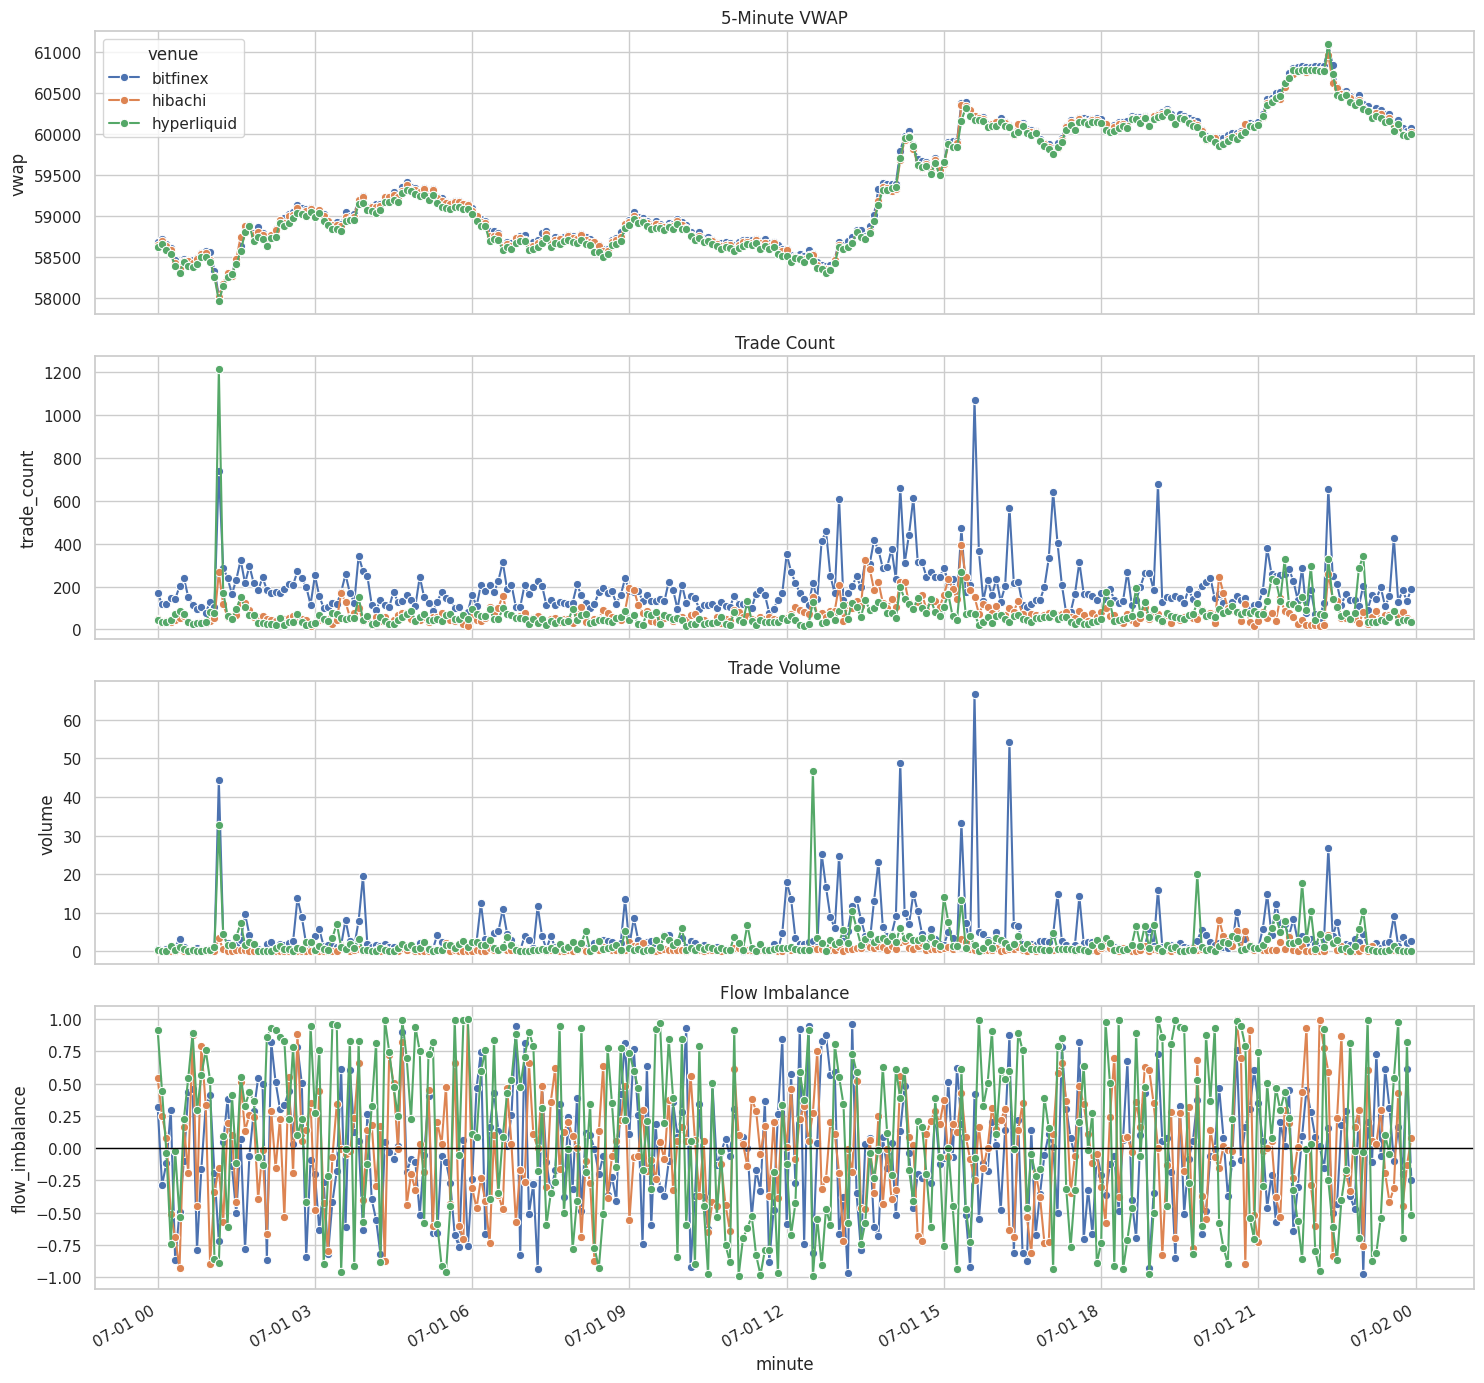

In [5]:
trade_pdf = trade_features.to_pandas()
fig, axes = plt.subplots(4, 1, figsize=(15, 14), sharex=True)
sns.lineplot(data=trade_pdf, x="minute", y="vwap", hue="venue", marker="o", ax=axes[0])
axes[0].set_title(f"{BAR_MINUTES}-Minute VWAP")
sns.lineplot(data=trade_pdf, x="minute", y="trade_count", hue="venue", marker="o", ax=axes[1], legend=False)
axes[1].set_title("Trade Count")
sns.lineplot(data=trade_pdf, x="minute", y="volume", hue="venue", marker="o", ax=axes[2], legend=False)
axes[2].set_title("Trade Volume")
sns.lineplot(data=trade_pdf, x="minute", y="flow_imbalance", hue="venue", marker="o", ax=axes[3], legend=False)
axes[3].axhline(0, color="black", linewidth=1)
axes[3].set_title("Flow Imbalance")
fig.autofmt_xdate(); plt.tight_layout()

## Book And Quote Features

In [6]:
book_features.head(30)

minute,mid,spread,top_imbalance,quote_count,venue,spread_bps,depth_imbalance,level_rows
datetime[μs],f64,f64,f64,u32,str,f64,f64,u32
2026-07-01 00:00:00,58683.297109,33.159529,null,null,"""bitfinex_updates""",5.650591,-0.082419,13433
2026-07-01 00:05:00,58726.236782,30.74023,null,null,"""bitfinex_updates""",5.234497,-0.091156,12314
2026-07-01 00:10:00,58673.186324,32.749059,null,null,"""bitfinex_updates""",5.581606,-0.022893,10788
2026-07-01 00:15:00,58620.315603,29.560284,null,null,"""bitfinex_updates""",5.042669,-0.024691,11996
2026-07-01 00:20:00,58477.001129,32.869074,null,null,"""bitfinex_updates""",5.620855,-0.004957,13236
2026-07-01 00:25:00,58381.528325,29.086207,null,null,"""bitfinex_updates""",4.982091,-0.142395,11298
2026-07-01 00:30:00,58483.310411,35.908309,null,null,"""bitfinex_updates""",6.139924,-0.290169,16227
2026-07-01 00:35:00,58469.945722,27.439336,null,null,"""bitfinex_updates""",4.692896,-0.147073,11251
2026-07-01 00:40:00,58452.646417,29.168224,null,null,"""bitfinex_updates""",4.990061,-0.141394,8631


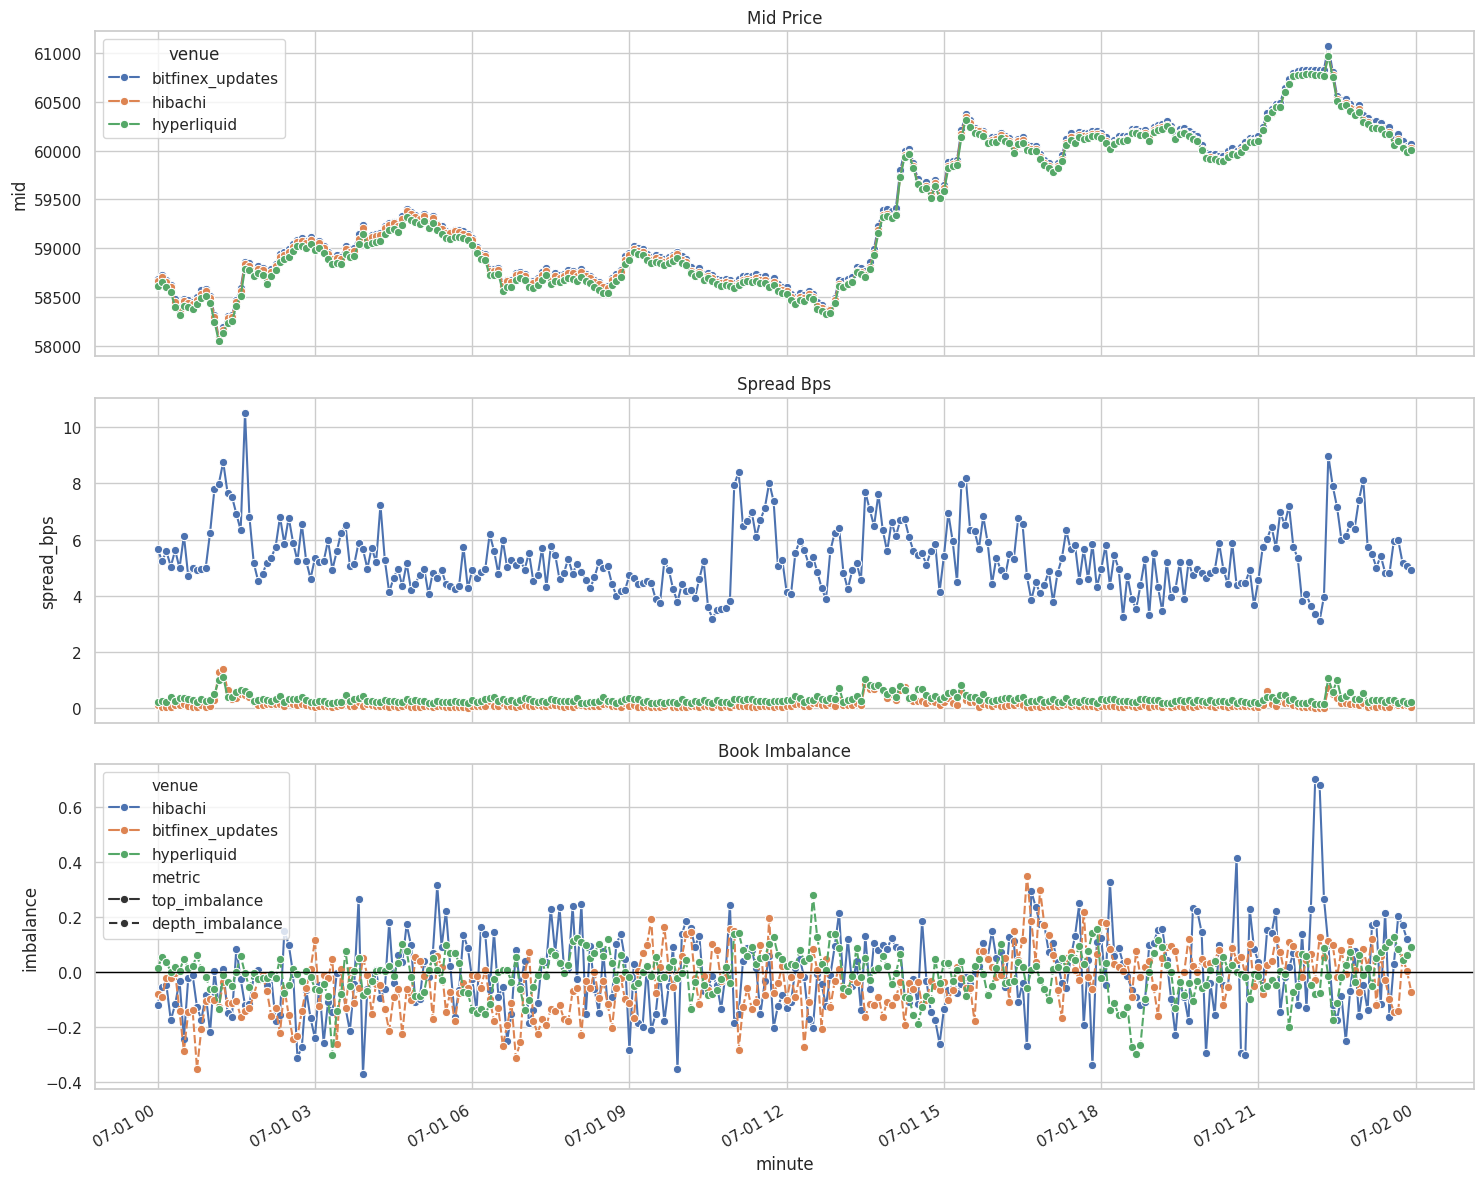

In [7]:
book_pdf = book_features.to_pandas()
fig, axes = plt.subplots(3, 1, figsize=(15, 12), sharex=True)
sns.lineplot(data=book_pdf, x="minute", y="mid", hue="venue", marker="o", ax=axes[0])
axes[0].set_title("Mid Price")
sns.lineplot(data=book_pdf, x="minute", y="spread_bps", hue="venue", marker="o", ax=axes[1], legend=False)
axes[1].set_title("Spread Bps")
imbalance_pdf = book_pdf.melt(
    id_vars=["minute", "venue"],
    value_vars=[column for column in ["top_imbalance", "depth_imbalance"] if column in book_pdf.columns],
    var_name="metric",
    value_name="imbalance",
).dropna()
sns.lineplot(data=imbalance_pdf, x="minute", y="imbalance", hue="venue", style="metric", marker="o", ax=axes[2])
axes[2].axhline(0, color="black", linewidth=1)
axes[2].set_title("Book Imbalance")
fig.autofmt_xdate(); plt.tight_layout()

## Realized Volatility And Bipower Variation Features

In [8]:
rv_features.tail(30)

,reference_price,log_price,ret_5m,ret_15m,ret_30m,ret_60m,rv_5m,bpv_5m,jump_var_5m,jump_share_5m,rv_15m,bpv_15m,jump_var_15m,jump_share_15m,rv_30m,bpv_30m,jump_var_30m,jump_share_30m,rv_5m_over_30m,bpv_5m_over_rv_5m
minute,,,,,,,,,,,,,,,,,,,,
2026-07-01 21:30:00,60601.715994,11.012078,0.002496,0.003506,0.008136,0.010347,0.809290,0.213055,0.609559,0.930694,0.497096,0.309996,0.151007,0.611106,0.511707,0.478129,0.033237,0.126935,1.581550,0.263261
2026-07-01 21:35:00,60684.959495,11.013451,0.001373,0.003979,0.007836,0.011989,0.445051,0.752172,0.000000,0.000000,0.533634,0.560141,0.000000,0.000000,0.495805,0.571635,0.000000,0.000000,0.897634,1.690080
2026-07-01 21:40:00,60768.563889,11.014828,0.001377,0.005246,0.007133,0.012650,0.446367,0.558613,0.000000,0.000000,0.592246,0.679413,0.000000,0.000000,0.450864,0.523733,0.000000,0.000000,0.990024,1.251466
2026-07-01 21:45:00,60780.068517,11.015017,0.000189,0.002939,0.006445,0.012148,0.061376,0.207445,0.000000,0.000000,0.365641,0.678544,0.000000,0.000000,0.436347,0.471813,0.000000,0.000000,0.140658,3.379934
2026-07-01 21:50:00,60779.125404,11.015002,-0.000016,0.001551,0.005529,0.011276,0.005031,0.022023,0.000000,0.000000,0.260151,0.421644,0.000000,0.000000,0.419788,0.443415,0.000000,0.000000,0.011984,4.377572
2026-07-01 21:55:00,60783.521616,11.015074,0.000072,0.000246,0.005492,0.011403,0.023450,0.013613,0.000365,0.663010,0.038045,0.147824,0.000000,0.000000,0.419644,0.439751,0.000000,0.000000,0.055882,0.580508
2026-07-01 22:00:00,60779.013535,11.015000,-0.000074,-0.000017,0.002921,0.011058,0.024047,0.029762,0.000000,0.000000,0.019609,0.027894,0.000000,0.000000,0.258919,0.429511,0.000000,0.000000,0.092875,1.237665
2026-07-01 22:05:00,60776.342172,11.014956,-0.000044,-0.000046,0.001505,0.009341,0.014251,0.023201,0.000000,0.000000,0.021066,0.028367,0.000000,0.000000,0.184557,0.267274,0.000000,0.000000,0.077215,1.628083
2026-07-01 22:10:00,60775.475253,11.014942,-0.000014,-0.000132,0.000114,0.007247,0.004625,0.010175,0.000000,0.000000,0.016358,0.027637,0.000000,0.000000,0.029283,0.095112,0.000000,0.000000,0.157934,2.200041


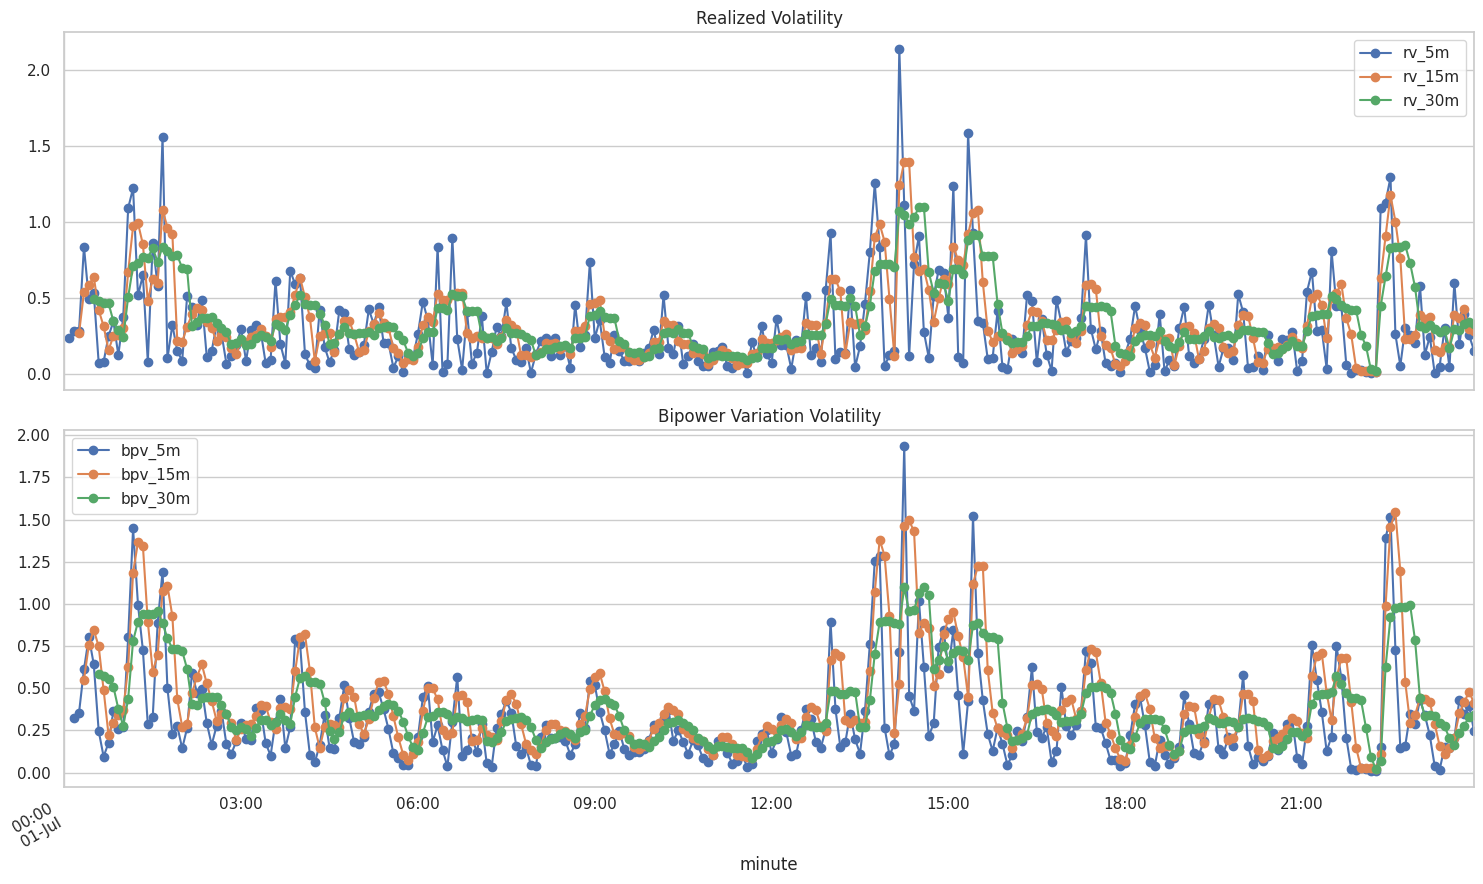

In [9]:
plot_realized_vol(rv_features)

## Deribit IV Term Structure Features

In [10]:
term_structure_features.tail(30)

,iv_0_7d,iv_30_90d,iv_7_30d,iv_90d_plus,iv_0_7d_count,iv_30_90d_count,iv_7_30d_count,iv_90d_plus_count,atm_call,atm_put,atm_put_call_iv_spread,term_slope_30_90_minus_0_7,term_slope_90_plus_minus_7_30,term_curvature,short_iv_decimal
minute,,,,,,,,,,,,,,,
2026-07-01 21:30:00,44.970,41.125,41.485,44.390,136,72,114,76,43.775,43.650,-0.125,-3.845,2.905,-3.5550,0.41485
2026-07-01 21:35:00,43.540,40.610,43.710,44.850,138,72,114,72,44.065,44.060,-0.005,-2.930,1.140,-3.5850,0.43710
2026-07-01 21:40:00,45.390,40.595,41.750,44.265,140,72,114,66,45.060,45.115,0.055,-4.795,2.515,-4.2325,0.41750
2026-07-01 21:45:00,44.490,41.610,43.070,44.090,136,72,114,74,44.135,44.160,0.025,-2.880,1.020,-2.6800,0.43070
2026-07-01 21:50:00,44.810,41.670,40.380,43.710,134,63,106,64,44.020,44.005,-0.015,-3.140,3.330,-2.5900,0.40380
2026-07-01 21:55:00,45.080,40.650,41.280,44.490,136,58,108,61,44.110,44.115,0.005,-4.430,3.210,-4.1350,0.41280
2026-07-01 22:00:00,45.775,41.010,40.205,44.010,132,60,104,52,44.195,44.190,-0.005,-4.765,3.805,-3.8825,0.40205
2026-07-01 22:05:00,45.450,42.770,40.505,43.400,132,42,88,58,44.915,44.900,-0.015,-2.680,2.895,-1.6550,0.40505
2026-07-01 22:10:00,45.890,42.780,43.125,42.940,132,48,74,44,45.585,45.570,-0.015,-3.110,-0.185,-1.6350,0.43125


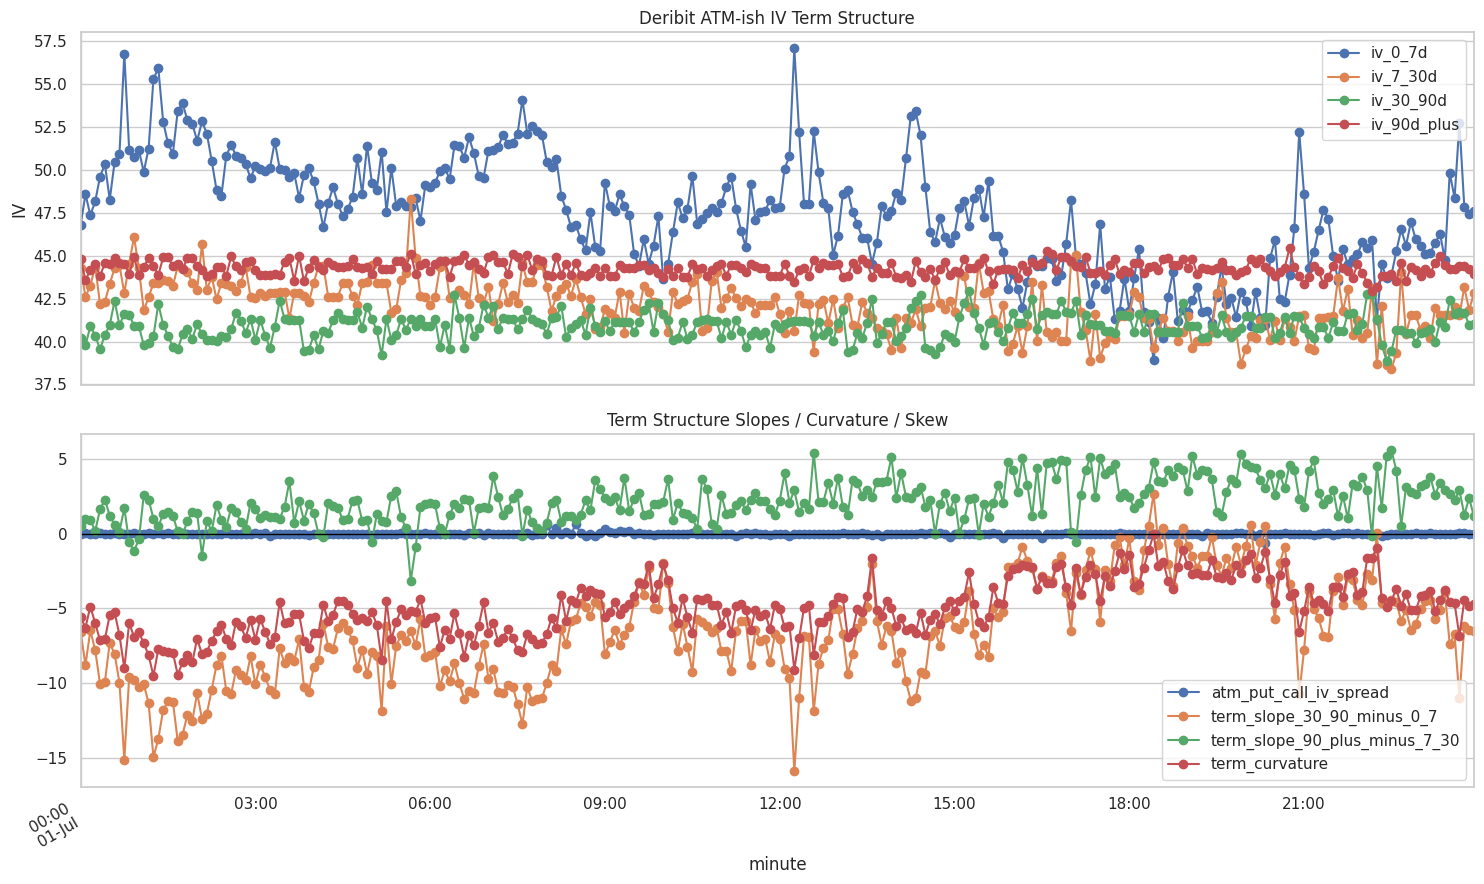

In [11]:
plot_term_structure(term_structure_features)

## Deribit Option Smile Features

In [12]:
option_smile_features.tail(30)

,smile_atm_call_iv,smile_atm_put_iv,smile_otm_call_iv,smile_otm_put_iv,smile_atm_call_iv_count,smile_atm_put_iv_count,smile_otm_call_iv_count,smile_otm_put_iv_count,smile_put_wing_minus_atm,smile_call_wing_minus_atm,smile_risk_reversal_proxy,smile_butterfly_proxy
minute,,,,,,,,,,,,
2026-07-01 21:30:00,40.550,40.475,38.190,54.125,1655,1662,775,1160,13.6125,-2.3225,-15.935,5.6450
2026-07-01 21:35:00,41.090,40.830,39.200,54.460,1567,1567,690,1009,13.5000,-1.7600,-15.260,5.8700
2026-07-01 21:40:00,41.615,41.610,38.660,56.340,1922,1909,639,1056,14.7275,-2.9525,-17.680,5.8875
2026-07-01 21:45:00,40.745,40.760,39.780,54.985,1654,1652,391,796,14.2325,-0.9725,-15.205,6.6300
2026-07-01 21:50:00,40.745,40.750,38.095,56.020,1098,1094,376,618,15.2725,-2.6525,-17.925,6.3100
2026-07-01 21:55:00,41.590,41.600,37.905,54.240,875,874,274,388,12.6450,-3.6900,-16.335,4.4775
2026-07-01 22:00:00,41.725,41.720,37.970,52.800,782,779,229,376,11.0775,-3.7525,-14.830,3.6625
2026-07-01 22:05:00,41.265,41.255,41.070,55.925,818,814,161,368,14.6650,-0.1900,-14.855,7.2375
2026-07-01 22:10:00,40.920,40.905,47.970,55.730,651,650,203,304,14.8175,7.0575,-7.760,10.9375


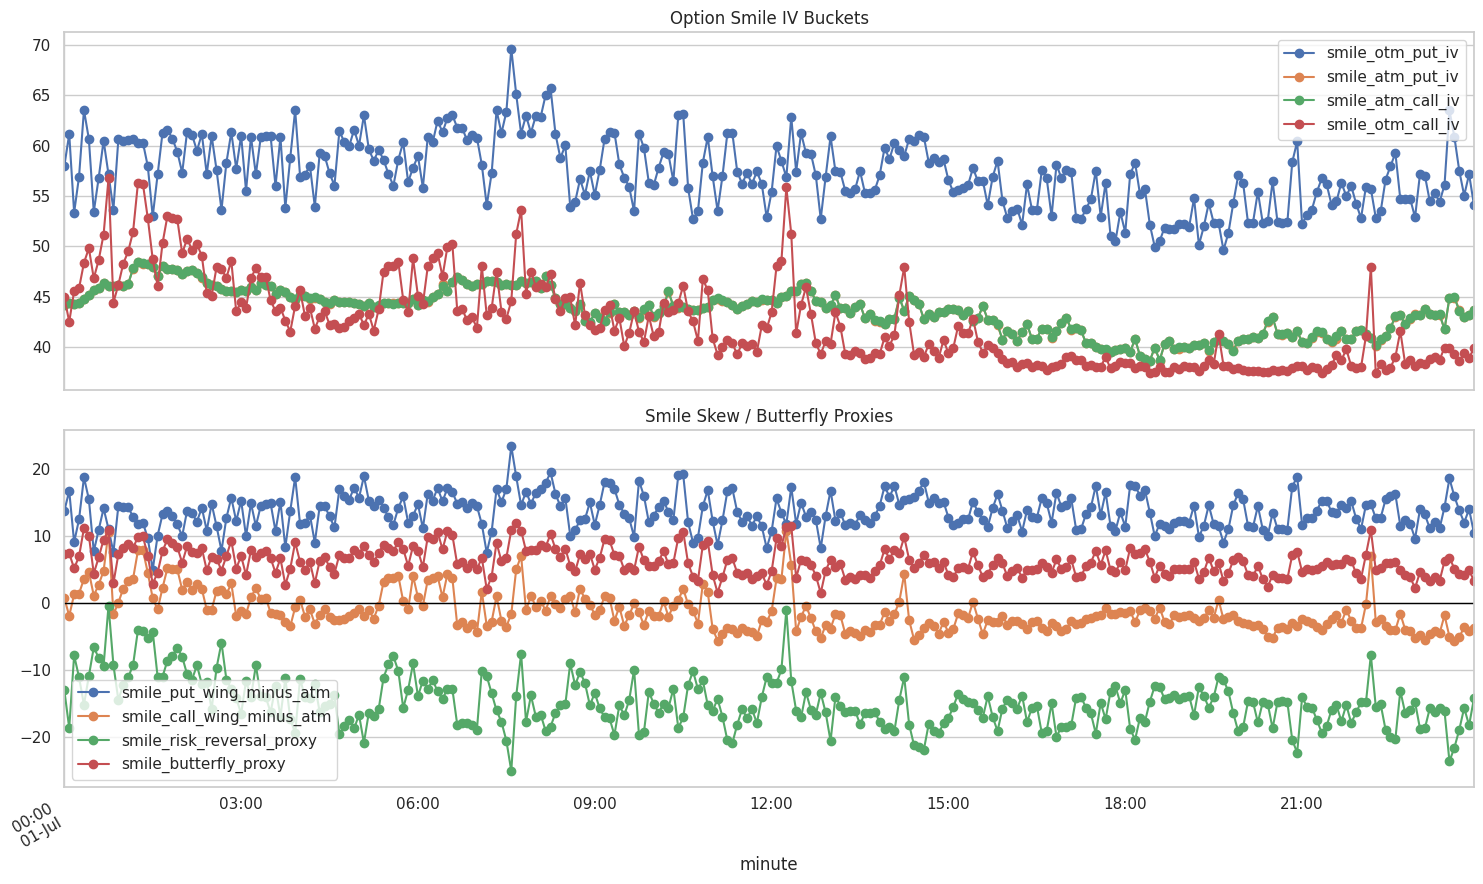

In [13]:
smile_cols = [column for column in ["smile_otm_put_iv", "smile_atm_put_iv", "smile_atm_call_iv", "smile_otm_call_iv"] if column in option_smile_features]
fig, axes = plt.subplots(2, 1, figsize=(15, 9), sharex=True)
option_smile_features[smile_cols].plot(ax=axes[0], marker="o")
axes[0].set_title("Option Smile IV Buckets")
smile_spread_cols = [column for column in option_smile_features.columns if column.endswith("proxy") or column.endswith("minus_atm")]
option_smile_features[smile_spread_cols].plot(ax=axes[1], marker="o")
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_title("Smile Skew / Butterfly Proxies")
fig.autofmt_xdate(); plt.tight_layout()

## Deribit Futures Basis Features

In [14]:
futures_basis_features.tail(30)

,basis_fut_0_7d,basis_fut_30_90d,basis_fut_7_30d,basis_fut_90d_plus,basis_fut_perp,basis_fut_0_7d_annualized,basis_fut_30_90d_annualized,basis_fut_7_30d_annualized,basis_fut_90d_plus_annualized,basis_fut_perp_annualized,basis_fut_0_7d_count,basis_fut_30_90d_count,basis_fut_7_30d_count,basis_fut_90d_plus_count,basis_fut_perp_count,basis_future_basis_slope_30_90_minus_0_7,basis_future_basis_slope_90_plus_minus_7_30
minute,,,,,,,,,,,,,,,,,
2026-07-01 21:30:00,1.582014,83.769587,10.739136,288.708895,2.522590,259.214725,357.888127,270.426465,394.032503,NaN,4,2,3,3,1,82.187573,277.969759
2026-07-01 21:35:00,1.665275,83.846480,11.131477,288.614647,2.784657,302.212605,358.222903,274.194198,393.910425,NaN,4,2,3,3,1,82.181205,277.483170
2026-07-01 21:40:00,2.522568,85.063374,12.794650,289.888696,5.194662,528.992552,363.436414,300.994633,395.653222,NaN,4,2,3,3,1,82.540807,277.094046
2026-07-01 21:45:00,3.045541,85.914075,12.647385,290.851217,5.643496,593.236767,367.084535,303.072737,396.971722,NaN,4,2,3,3,1,82.868534,278.203831
2026-07-01 21:50:00,2.650524,86.254276,13.814983,290.394315,5.823309,521.003227,368.559930,330.484733,396.356123,NaN,4,2,3,3,1,83.603752,276.579332
2026-07-01 21:55:00,2.900305,85.800343,13.743922,291.508118,7.121491,703.482968,366.626047,328.674967,397.882436,NaN,4,2,3,3,1,82.900038,277.764197
2026-07-01 22:00:00,4.035763,85.975613,13.948261,291.373473,7.077883,831.347468,367.392770,331.602241,397.700103,NaN,4,2,3,3,1,81.939850,277.425212
2026-07-01 22:05:00,3.693286,85.555998,14.057039,291.792983,5.065461,844.576641,365.616419,334.024358,398.280422,NaN,4,2,3,3,1,81.862712,277.735944
2026-07-01 22:10:00,3.487758,85.744369,13.797136,291.703843,4.709622,894.611936,366.439965,329.248389,398.164035,NaN,4,2,3,3,1,82.256612,277.906707


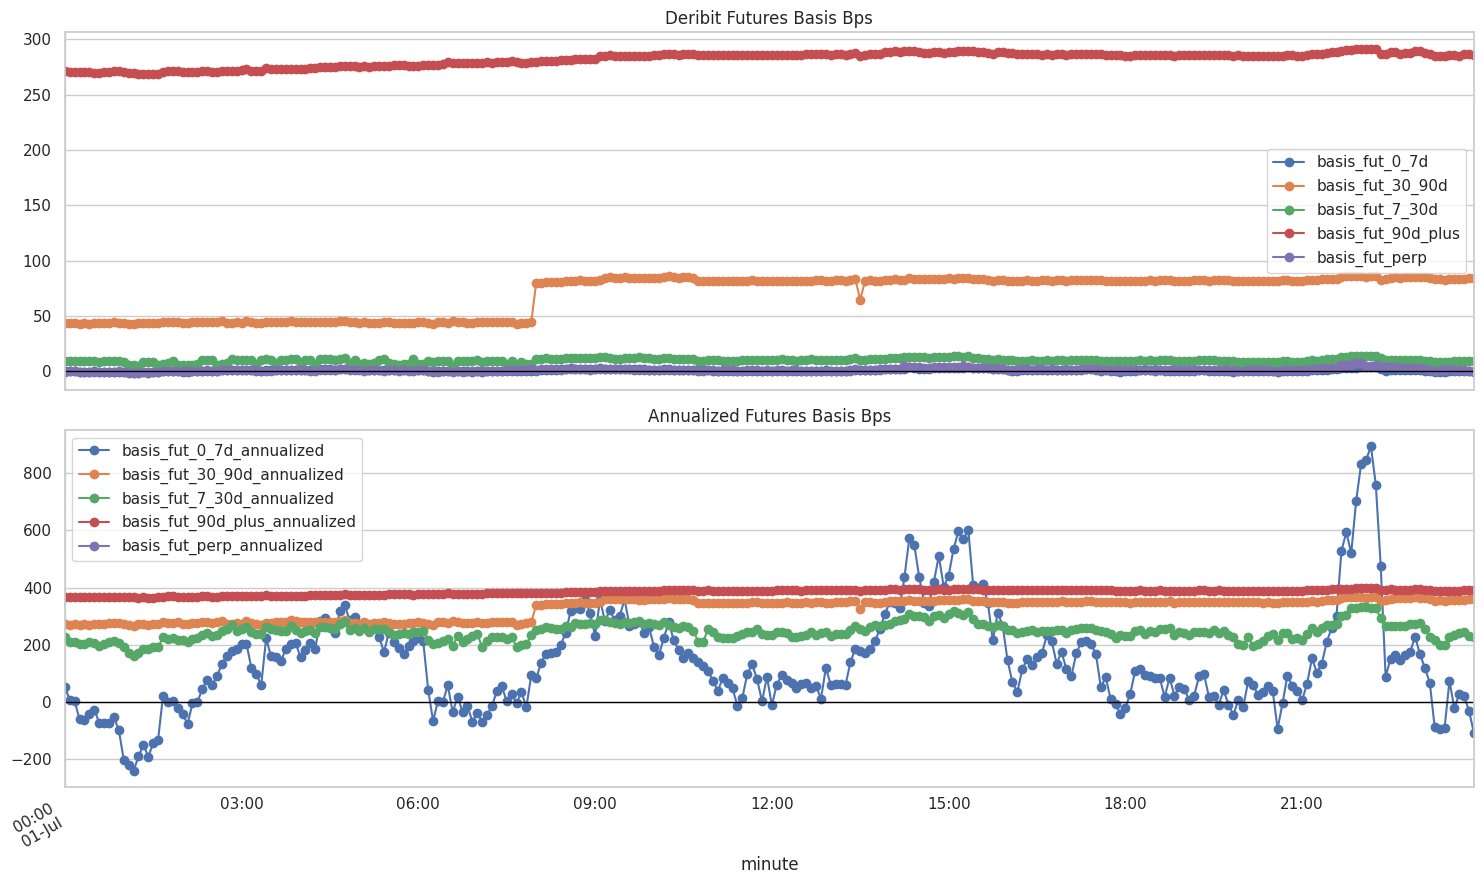

In [15]:
basis_cols = [column for column in futures_basis_features.columns if column.startswith("basis_fut_") and not column.endswith("count") and not column.endswith("annualized")]
ann_cols = [column for column in futures_basis_features.columns if column.endswith("annualized")]
fig, axes = plt.subplots(2, 1, figsize=(15, 9), sharex=True)
futures_basis_features[basis_cols].plot(ax=axes[0], marker="o")
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_title("Deribit Futures Basis Bps")
futures_basis_features[ann_cols].plot(ax=axes[1], marker="o")
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_title("Annualized Futures Basis Bps")
fig.autofmt_xdate(); plt.tight_layout()

## Funding Features

In [16]:
funding_features.tail(30)

,estimated_funding_rate,funding_updates
minute,,
2026-07-01 21:30:00,-0.000007,991
2026-07-01 21:35:00,-0.000006,990
2026-07-01 21:40:00,-0.000007,990
2026-07-01 21:45:00,-0.000007,991
2026-07-01 21:50:00,-0.000009,990
2026-07-01 21:55:00,-0.000008,990
2026-07-01 22:00:00,-0.000008,990
2026-07-01 22:05:00,-0.000010,990
2026-07-01 22:10:00,-0.000010,990


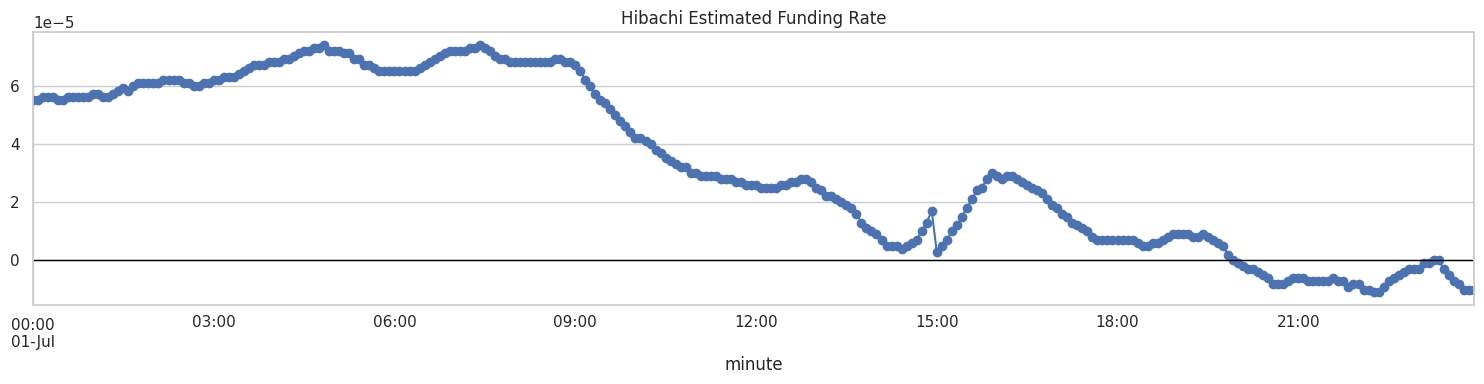

In [17]:
fig, ax = plt.subplots(figsize=(15, 4))
funding_features["estimated_funding_rate"].plot(ax=ax, marker="o")
ax.axhline(0, color="black", linewidth=1)
ax.set_title("Hibachi Estimated Funding Rate")
plt.tight_layout()

## Feature Matrix

In [18]:
feature_matrix.tail(20)

,trade_flow_imbalance_bitfinex,trade_flow_imbalance_hibachi,trade_flow_imbalance_hyperliquid,trade_trade_count_bitfinex,trade_trade_count_hibachi,trade_trade_count_hyperliquid,trade_volume_bitfinex,trade_volume_hibachi,trade_volume_hyperliquid,trade_vwap_bitfinex,trade_vwap_hibachi,trade_vwap_hyperliquid,book_depth_imbalance_bitfinex_updates,book_depth_imbalance_hyperliquid,book_mid_bitfinex_updates,book_mid_hibachi,book_mid_hyperliquid,book_spread_bps_bitfinex_updates,book_spread_bps_hibachi,book_spread_bps_hyperliquid,book_top_imbalance_hibachi,option_tick_count,active_options,median_mark_iv,median_index_price,open_interest_sum,estimated_funding_rate,funding_updates,mid_hibachi_minus_hyperliquid,mid_hibachi_minus_hyperliquid_bps,spread_bps_hibachi_minus_hyperliquid,cross_venue_flow_imbalance_mean,cross_venue_flow_imbalance_std,cross_venue_volume_sum,cross_venue_spread_bps_mean,cross_venue_spread_bps_std,reference_price,log_price,ret_5m,ret_15m,ret_30m,ret_60m,rv_5m,bpv_5m,jump_var_5m,jump_share_5m,rv_15m,bpv_15m,jump_var_15m,jump_share_15m,rv_30m,bpv_30m,jump_var_30m,jump_share_30m,rv_5m_over_30m,bpv_5m_over_rv_5m,iv_0_7d,iv_30_90d,iv_7_30d,iv_90d_plus,iv_0_7d_count,iv_30_90d_count,iv_7_30d_count,iv_90d_plus_count,atm_call,atm_put,atm_put_call_iv_spread,term_slope_30_90_minus_0_7,term_slope_90_plus_minus_7_30,term_curvature,short_iv_decimal,smile_atm_call_iv,smile_atm_put_iv,smile_otm_call_iv,smile_otm_put_iv,smile_atm_call_iv_count,smile_atm_put_iv_count,smile_otm_call_iv_count,smile_otm_put_iv_count,smile_put_wing_minus_atm,smile_call_wing_minus_atm,smile_risk_reversal_proxy,smile_butterfly_proxy,basis_fut_0_7d,basis_fut_30_90d,basis_fut_7_30d,basis_fut_90d_plus,basis_fut_perp,basis_fut_0_7d_annualized,basis_fut_30_90d_annualized,basis_fut_7_30d_annualized,basis_fut_90d_plus_annualized,basis_fut_perp_annualized,basis_fut_0_7d_count,basis_fut_30_90d_count,basis_fut_7_30d_count,basis_fut_90d_plus_count,basis_fut_perp_count,basis_future_basis_slope_30_90_minus_0_7,basis_future_basis_slope_90_plus_minus_7_30,trade_flow_imbalance_bitfinex_diff_5m,trade_flow_imbalance_bitfinex_mean_5m,trade_flow_imbalance_bitfinex_z_5m,trade_flow_imbalance_bitfinex_mean_15m,trade_flow_imbalance_bitfinex_z_15m,trade_flow_imbalance_bitfinex_mean_30m,trade_flow_imbalance_bitfinex_z_30m,trade_flow_imbalance_hibachi_diff_5m,trade_flow_imbalance_hibachi_mean_5m,trade_flow_imbalance_hibachi_z_5m,trade_flow_imbalance_hibachi_mean_15m,trade_flow_imbalance_hibachi_z_15m,trade_flow_imbalance_hibachi_mean_30m,trade_flow_imbalance_hibachi_z_30m,trade_flow_imbalance_hyperliquid_diff_5m,trade_flow_imbalance_hyperliquid_mean_5m,trade_flow_imbalance_hyperliquid_z_5m,trade_flow_imbalance_hyperliquid_mean_15m,trade_flow_imbalance_hyperliquid_z_15m,trade_flow_imbalance_hyperliquid_mean_30m,...,jump_share_5m_z_30m,rv_15m_diff_5m,rv_15m_mean_5m,rv_15m_z_5m,rv_15m_mean_15m,rv_15m_z_15m,rv_15m_mean_30m,rv_15m_z_30m,bpv_15m_diff_5m,bpv_15m_mean_5m,bpv_15m_z_5m,bpv_15m_mean_15m,bpv_15m_z_15m,bpv_15m_mean_30m,bpv_15m_z_30m,jump_var_15m_diff_5m,jump_var_15m_mean_5m,jump_var_15m_z_5m,jump_var_15m_mean_15m,jump_var_15m_z_15m,jump_var_15m_mean_30m,jump_var_15m_z_30m,jump_share_15m_diff_5m,jump_share_15m_mean_5m,jump_share_15m_z_5m,jump_share_15m_mean_15m,jump_share_15m_z_15m,jump_share_15m_mean_30m,jump_share_15m_z_30m,rv_30m_diff_5m,rv_30m_mean_5m,rv_30m_z_5m,rv_30m_mean_15m,rv_30m_z_15m,rv_30m_mean_30m,rv_30m_z_30m,bpv_30m_diff_5m,bpv_30m_mean_5m,bpv_30m_z_5m,bpv_30m_mean_15m,bpv_30m_z_15m,bpv_30m_mean_30m,bpv_30m_z_30m,jump_var_30m_diff_5m,jump_var_30m_mean_5m,jump_var_30m_z_5m,jump_var_30m_mean_15m,jump_var_30m_z_15m,jump_var_30m_mean_30m,jump_var_30m_z_30m,jump_share_30m_diff_5m,jump_share_30m_mean_5m,jump_share_30m_z_5m,jump_share_30m_mean_15m,jump_share_30m_z_15m,jump_share_30m_mean_30m,jump_share_30m_z_30m,rv_5m_over_30m_diff_5m,rv_5m_over_30m_mean_5m,rv_5m_over_30m_z_5m,rv_5m_over_30m_mean_15m,rv_5m_over_30m_z_15m,rv_5m_over_30m_mean_30m,rv_5m_over_30m_z_30m,bpv_5m_o

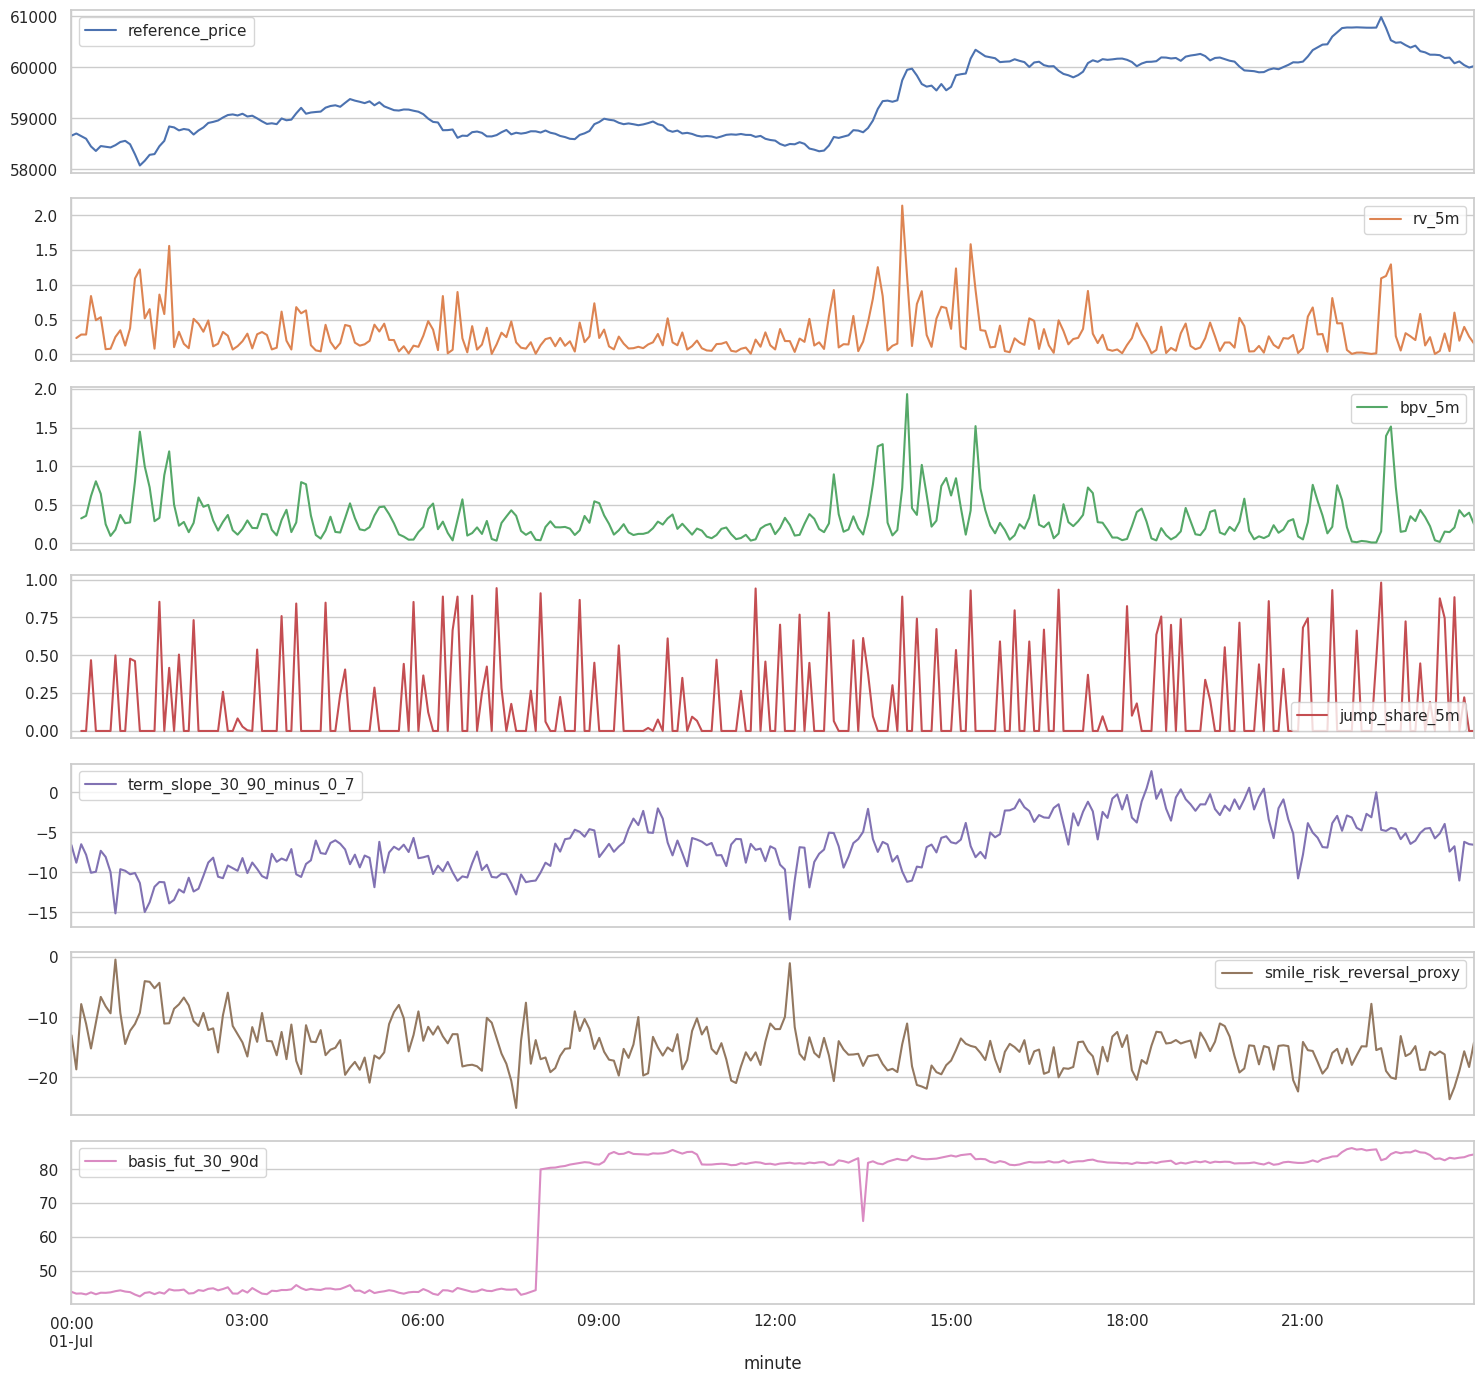

In [19]:
selected = [
    column for column in feature_matrix.columns
    if column in ["reference_price", "rv_5m", "bpv_5m", "jump_share_5m", "term_slope_30_90_minus_0_7", "smile_risk_reversal_proxy", "basis_fut_30_90d"]
]
feature_matrix[selected].plot(figsize=(15, max(4, 2 * len(selected))), subplots=True, layout=(len(selected), 1), sharex=True, legend=True)
plt.tight_layout()

## Optional Save

In [20]:
if SAVE_OUTPUTS:
    out_dir = FEATURE_ROOT / DATE / f"bar_{BAR_MINUTES}m"
    out_dir.mkdir(parents=True, exist_ok=True)
    feature_matrix.to_parquet(out_dir / "feature_matrix.parquet")
    base_feature_matrix.to_parquet(out_dir / "base_feature_matrix.parquet")
    print(f"wrote features to {out_dir}")
else:
    print("SAVE_OUTPUTS is false; nothing written")

SAVE_OUTPUTS is false; nothing written
